# Transformers

In [2]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import joblib, os

In [4]:
df = pd.read_csv("data/master_dataset.csv")


In [5]:
# ── Modelo de embeddings ──────────────────────────────────────────────
# all-mpnet-base-v2 es el mejor balance calidad/velocidad
print("Cargando modelo de embeddings...")
embedder = SentenceTransformer("all-mpnet-base-v2")

Cargando modelo de embeddings...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\Natalia\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Natalia\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
# ── Generar embeddings para todas las sinopsis ────────────────────────
print("Generando embeddings...")
synopses = df["synopsis"].fillna("").tolist()
embeddings = embedder.encode(
    synopses,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True   # cosine similarity
)

print(f"Shape embeddings: {embeddings.shape}")  # (170, 768)

Generando embeddings...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Shape embeddings: (170, 768)


In [7]:
# ── Guardar para no recalcular ────────────────────────────────────────
os.makedirs("models", exist_ok=True)
np.save("models/synopsis_embeddings.npy", embeddings)
print("Embeddings guardados.")

Embeddings guardados.


In [8]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import joblib

In [9]:
GOLD, RED, DARK_RED = "#D4AF37", "#C0392B", "#8B0000"
BG, PANEL_BG, TEXT  = "#F5F0E8", "#EDE8DE", "#1A1A1A"

embeddings = np.load("models/synopsis_embeddings.npy")

In [10]:
# ── Splits ────────────────────────────────────────────────────────────
train_years = list(range(2005, 2017))
val_years   = list(range(2017, 2022))
test_years  = list(range(2022, 2026))

train_mask    = df["ceremony_year"].isin(train_years)
val_mask      = df["ceremony_year"].isin(val_years)
test_mask     = df["ceremony_year"].isin(test_years)
trainval_mask = df["ceremony_year"].isin(train_years + val_years)

E_train = embeddings[train_mask]
E_val   = embeddings[val_mask]
E_test  = embeddings[test_mask]
E_tv    = embeddings[trainval_mask]

y_train = df.loc[train_mask,    "won_best_picture"].values
y_val   = df.loc[val_mask,      "won_best_picture"].values
y_tv    = df.loc[trainval_mask, "won_best_picture"].values


In [11]:
# ── PCA: reducir 768 → n componentes ─────────────────────────────────
# Tuneamos n_components en val
best_n, best_c, best_acc_emb = None, None, 0

for n_comp in [10, 20, 30, 50]:
    pca     = PCA(n_components=n_comp, random_state=42)
    scaler  = StandardScaler()
    
    E_tr_r  = scaler.fit_transform(pca.fit_transform(E_train))
    E_vl_r  = scaler.transform(pca.transform(E_val))
    
    for C in [0.001, 0.01, 0.1, 1.0]:
        lr = LogisticRegression(C=C, class_weight="balanced",
                                max_iter=1000, random_state=42)
        lr.fit(E_tr_r, y_train)
        
        # Percentil de la ganadora en val
        scores = []
        val_df = df[val_mask].reset_index(drop=True)
        probs_val = lr.predict_proba(E_vl_r)[:, 1]
        
        for year in val_years:
            mask_y     = val_df["ceremony_year"] == year
            probs_y    = probs_val[mask_y.values]
            probs_norm = probs_y / probs_y.sum()
            winner_p   = probs_norm[val_df.loc[mask_y, "won_best_picture"].values == 1][0]
            scores.append((probs_norm < winner_p).mean())
        
        acc = np.mean(scores)
        if acc > best_acc_emb:
            best_acc_emb = acc
            best_n, best_c = n_comp, C

print(f"Mejor n_components: {best_n}  |  C: {best_c}  |  Val score: {best_acc_emb:.3f}")


Mejor n_components: 20  |  C: 0.001  |  Val score: 0.142


In [12]:
# ── Reentrenar con train+val ──────────────────────────────────────────
pca_final    = PCA(n_components=best_n, random_state=42)
scaler_final = StandardScaler()

E_tv_r   = scaler_final.fit_transform(pca_final.fit_transform(E_tv))
E_test_r = scaler_final.transform(pca_final.transform(E_test))

lr_text = LogisticRegression(C=best_c, class_weight="balanced",
                              max_iter=1000, random_state=42)
lr_text.fit(E_tv_r, y_tv)

# ── Test ──────────────────────────────────────────────────────────────
print("\n── Modelo de Texto (Embeddings) — Test Set (2022-2025) ──────")
test_df_emb = df[test_mask].reset_index(drop=True)
probs_test  = lr_text.predict_proba(E_test_r)[:, 1]

text_results = []
for year in test_years:
    mask_y     = test_df_emb["ceremony_year"] == year
    probs_y    = probs_test[mask_y.values]
    probs_norm = probs_y / probs_y.sum()
    test_df_emb.loc[mask_y, "prob_text"] = probs_norm

    year_df   = test_df_emb[mask_y]
    pred      = year_df.sort_values("prob_text", ascending=False).iloc[0]["nominated_title"]
    real      = year_df[year_df["won_best_picture"] == 1]["nominated_title"].values[0]
    wprob     = year_df[year_df["won_best_picture"] == 1]["prob_text"].values[0]
    ok        = int(pred == real)

    print(f"{year} | Real: {real:<40} Pred: {pred:<40} {wprob:.1%} {'✅' if ok else '❌'}")
    text_results.append({"year": year, "real": real, "pred": pred,
                          "correct": ok, "winner_prob": wprob, "model": "TextEmb"})

text_df = pd.DataFrame(text_results)
print(f"\nAccuracy Texto: {text_df['correct'].mean():.1%}")

joblib.dump(lr_text,    "models/lr_text_oscar.pkl")
joblib.dump(pca_final,  "models/pca_text.pkl")
joblib.dump(scaler_final, "models/scaler_text.pkl")
print("Modelo de texto guardado.")


── Modelo de Texto (Embeddings) — Test Set (2022-2025) ──────
2022 | Real: CODA                                     Pred: Nightmare Alley                          10.0% ❌
2023 | Real: Everything Everywhere All at Once        Pred: Tár                                      11.2% ❌
2024 | Real: Oppenheimer                              Pred: American Fiction                         9.9% ❌
2025 | Real: Anora                                    Pred: Conclave                                 10.0% ❌

Accuracy Texto: 0.0%
Modelo de texto guardado.


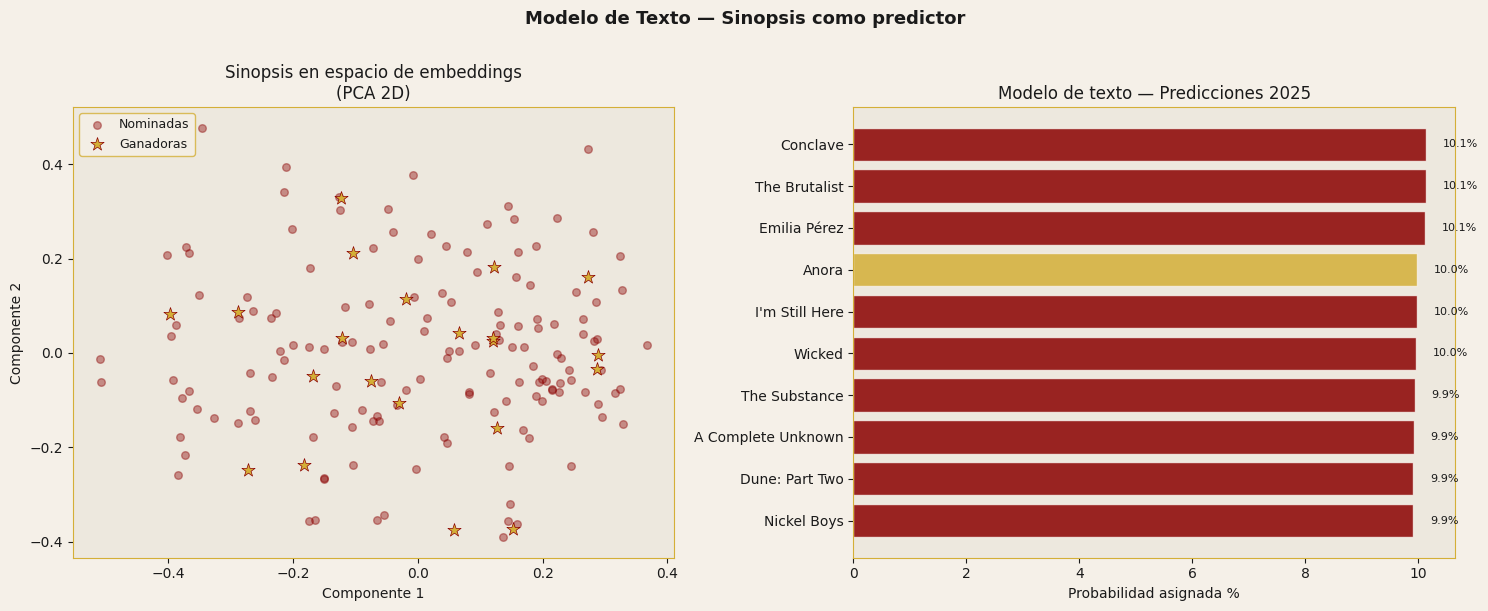

In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA as PCA2

# ── PCA 2D para visualizar clusters ──────────────────────────────────
pca_2d = PCA2(n_components=2, random_state=42)
E_2d   = pca_2d.fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Plot 1: ganadoras vs nominadas en espacio de embeddings ──────────
ax = axes[0]
mask_won  = df["won_best_picture"] == 1
mask_lost = df["won_best_picture"] == 0

ax.scatter(E_2d[mask_lost, 0], E_2d[mask_lost, 1],
           color=DARK_RED, alpha=0.4, s=30, label="Nominadas")
ax.scatter(E_2d[mask_won, 0],  E_2d[mask_won, 1],
           color=GOLD, s=100, zorder=5, marker="*",
           edgecolors=DARK_RED, linewidth=0.5, label="Ganadoras")
ax.set_title("Sinopsis en espacio de embeddings\n(PCA 2D)", color=TEXT)
ax.set_xlabel("Componente 1", color=TEXT)
ax.set_ylabel("Componente 2", color=TEXT)
ax.legend(fontsize=9, facecolor=BG, edgecolor=GOLD, labelcolor=TEXT)
ax.tick_params(colors=TEXT)
ax.set_facecolor(PANEL_BG)
for spine in ax.spines.values(): spine.set_edgecolor(GOLD)

# ── Plot 2: probabilidades del modelo de texto para 2025 ─────────────
ax = axes[1]
year_2025 = test_df_emb[test_df_emb["ceremony_year"] == 2025].sort_values(
    "prob_text", ascending=True)

bar_colors = [GOLD if w == 1 else DARK_RED
              for w in year_2025["won_best_picture"].values]
bars = ax.barh(year_2025["nominated_title"], year_2025["prob_text"] * 100,
               color=bar_colors, alpha=0.85, edgecolor=BG)
ax.set_xlabel("Probabilidad asignada %", color=TEXT)
ax.set_title("Modelo de texto — Predicciones 2025", color=TEXT)
ax.tick_params(colors=TEXT)
ax.set_facecolor(PANEL_BG)
for spine in ax.spines.values(): spine.set_edgecolor(GOLD)
for bar, val in zip(bars, year_2025["prob_text"] * 100):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8, color=TEXT)

fig.patch.set_facecolor(BG)
plt.suptitle("Modelo de Texto — Sinopsis como predictor",
             fontsize=13, color=TEXT, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("img/text_model.png", dpi=130, bbox_inches="tight", facecolor=BG)
plt.show()